In [1]:
pip install pygame

Note: you may need to restart the kernel to use updated packages.


In [31]:
import time
import matplotlib.pyplot as plt
import numpy as np
import pygame

In [26]:
class Maquina_basica: 

    def __init__(self,ficha):
        self.profundidad = 2 # fijamos la profundidad de la máquina básica
        self.ficha = ficha # ficha con la que va a jugar la máquina
        
    def jugar(self, juego, tablero_actual): # calcula la mejor jugada para ella teniendo en cuenta la ficha que está utilizando en el juego
        _, col = juego.minimax(
            tablero_actual,
            self.profundidad,
            float('-inf'),
            float('inf'),
            True,
            self.ficha
        )
        return col

class Maquina_avanzada: 

    def __init__(self, profundidad, ficha):
        self.profundidad = profundidad # dejamos la profundidad de la máquina avanzada como parametro de entrada
        self.ficha = ficha # ficha con la que va a jugar la máquina
        
    def jugar(self, juego, tablero_actual): # calcula la mejor jugada para ella teniendo en cuenta la ficha que está utilizando en el juego
        _, col = juego.minimax(
            tablero_actual,
            self.profundidad,
            float('-inf'),
            float('inf'),
            True,
            self.ficha
        )
        return col
    
class Conecta4:

    def __init__(self):
        self.filas = 6
        self.columnas = 7
        self.tablero = [[0 for _ in range(self.columnas)] for _ in range(self.filas)]


    # -----------------------------
    # chequear si está el tablero lleno
    # -----------------------------
    def tablero_lleno(self, tablero):
        return all(tablero[0][col] != 0 for col in range(self.columnas))

     # -----------------------------
    # chequear si hay ganador
    # -----------------------------
    def hay_ganador(self, tablero):
        # horizontales
        for f in range(self.filas):
            for c in range(self.columnas - 3):
                linea = [tablero[f][c+i] for i in range(4)]
                if linea == [1]*4:
                    return 1
                if linea == [2]*4:
                    return 2

        # verticales
        for f in range(self.filas - 3):
            for c in range(self.columnas):
                linea = [tablero[f+i][c] for i in range(4)]
                if linea == [1]*4:
                    return 1
                if linea == [2]*4:
                    return 2

        # diagonal positiva
        for f in range(self.filas - 3):
            for c in range(self.columnas - 3):
                linea = [tablero[f+i][c+i] for i in range(4)]
                if linea == [1]*4:
                    return 1
                if linea == [2]*4:
                    return 2

        # diagonal negativa
        for f in range(3, self.filas):
            for c in range(self.columnas - 3):
                linea = [tablero[f-i][c+i] for i in range(4)]
                if linea == [1]*4:
                    return 1
                if linea == [2]*4:
                    return 2

        return None
        
    # -----------------------------
    # chequear si el juego ha terminado
    # -----------------------------
    def terminado(self, tablero):
        return True if (self.tablero_lleno(tablero) or self.hay_ganador(tablero)) else False
        
    # -----------------------------
    # copiar el tablero (para no cambiarlo y analizar posibles jugadas)
    # -----------------------------
    def copiar_tablero(self, tablero):
        return [fila[:] for fila in tablero]

    # -----------------------------
    # colocar la ficha
    # -----------------------------
    def colocar_ficha(self, tablero, col, ficha):
        for fila in range(self.filas - 1, -1, -1):
            if tablero[fila][col] == 0:
                tablero[fila][col] = ficha
                return fila
        return None  # columna llena

    # -----------------------------
    # función evaluación
    # -----------------------------
    def evaluar_tablero(self, tablero, jugador):
        puntuacion = 0
        adversario = 1 if jugador == 2 else 2

        def evaluar_linea(linea):
            nonlocal puntuacion
            if linea.count(jugador) == 4:
                puntuacion += 1000
            elif linea.count(adversario) == 4:
                puntuacion -= 1000
            elif linea.count(jugador) == 3 and linea.count(0) == 1:
                puntuacion += 10
            elif linea.count(adversario) == 3 and linea.count(0) == 1:
                puntuacion -= 10
            elif linea.count(jugador) == 2 and linea.count(0) == 2:
                puntuacion += 1
            elif linea.count(adversario) == 2 and linea.count(0) == 2:
                puntuacion -= 1

        # horizontales
        for f in range(self.filas):
            for c in range(self.columnas - 3):
                evaluar_linea([tablero[f][c+i] for i in range(4)])

        # verticales
        for f in range(self.filas - 3):
            for c in range(self.columnas):
                evaluar_linea([tablero[f+i][c] for i in range(4)])

        # diagonal positiva
        for f in range(self.filas - 3):
            for c in range(self.columnas - 3):
                evaluar_linea([tablero[f+i][c+i] for i in range(4)])

        # diagonal negativa
        for f in range(3, self.filas):
            for c in range(self.columnas - 3):
                evaluar_linea([tablero[f-i][c+i] for i in range(4)])

        return puntuacion
        
    # -----------------------------
    # minimax con poda alpha-beta
    # -----------------------------
    def minimax(self, tablero, profundidad, alpha, beta, maximizar, jugador):
        adversario = 1 if jugador == 2 else 2
        
        if profundidad == 0 or self.hay_ganador(tablero) or self.tablero_lleno(tablero):
            return self.evaluar_tablero(tablero, jugador), None

        if maximizar: # si estamos maximizando (jugada de la máquina)
            max_eval = float('-inf')
            best_col = None

            for col in range(self.columnas):
                if tablero[0][col] != 0:
                    continue
                # para cada columna mira si está llena y en caso de no estarlo explora esa jugada:
                copia = self.copiar_tablero(tablero)
                self.colocar_ficha(copia, col, jugador) # coloca a ficha del jugador en la columna no llena

                eval_score, _ = self.minimax(copia, profundidad-1, alpha, beta, False, adversario) 

                if eval_score > max_eval: # compara la evaluación obtenida con la máxima anterior y actualiza en caso de ser mayor
                    max_eval = eval_score
                    best_col = col
                alpha = max(alpha, eval_score) # actualiza alpha con el mayor valor del nivel (beneficio para la máquina)
                if beta <= alpha: 
                    break

        
            return max_eval, best_col # devuelve la mejor jugada para la máquina en función de la posible siguiente mejor jugada del jugador
                
        else: # si estamos minimizando (previendo la jugada del jugador)
            min_eval = float('inf')
            best_col = None
    
            for col in range(self.columnas):
                if tablero[0][col] != 0:
                    continue
                # para cada columna mira si está llena y en caso de no estarlo explora esa jugada:
                copia = self.copiar_tablero(tablero)
                self.colocar_ficha(copia, col, adversario) # coloca a ficha del adversario en la columna no llena
    
                eval_score, _ = self.minimax(copia, profundidad-1, alpha, beta, True, jugador) 
    
                if eval_score < min_eval: # compara la evaluación obtenida con la mínima anterior y actualiza en caso de ser menor
                    min_eval = eval_score
                    best_col = col
    
                beta = min(beta, eval_score) # actualiza beta con el menor valor del nivel (beneficio para el jugador)
                if beta <= alpha:
                    break

    
            return min_eval, best_col # devuelve la mejor jugada para el jugador en función de la posible siguiente mejor jugada de la máquina
            # (no en el caso básico de profundidad=1)
    # -----------------------------
    # recursión del juego
    # -----------------------------
    def jugar_partida(self, jugador1, jugador2):
        jugador_actual = 1
        
        while not self.terminado(self.tablero):
    
            if jugador_actual == jugador1.ficha:
                col = jugador1.jugar(self, self.tablero)
            else:
                col = jugador2.jugar(self, self.tablero)

            self.colocar_ficha(self.tablero, col, jugador_actual)
            
            jugador_actual = 2 if jugador_actual == 1 else 1
            

        return self.hay_ganador(self.tablero)
    
        

In [34]:
partidas_ganadas = [0]*5; duracion_partidas = [0]*5

for n in range(5):

    for i in range(100):

        juego = Conecta4()
        
        if i % 2 == 0:
            maquina1 = Maquina_basica(1)
            maquina2 = Maquina_avanzada(profundidad = n+1, ficha = 2)



        else:
            maquina1 = Maquina_basica(2)
            maquina2 = Maquina_avanzada(profundidad = n+1, ficha = 1)
            
        inicio = time.time()
        ganador = juego.jugar_partida(maquina1, maquina2)
        fin = time.time()
        duracion_partidas[n] += fin - inicio
        
        if ganador == maquina2.ficha:
            partidas_ganadas[n] += 1

                
    partidas_ganadas[n] /= 100; duracion_partidas[n] /= 100; # calculamos la probabilidad de ganar la partida para cada profundidad
        

print(partidas_ganadas)
# Profundidad de la máquina1 = 2 y máquina2 = [1,2,3,4,5]
    # si la profundidad de la máquina2 < máquina1 ---> máquina2 NUNCA gana
    # si la profundidad de la máquina2 == máquina1 ---> máquina2 y máquina1 MISMAS PROBABILIDADES de ganar
    # si la profundidad de la máquina2 > máquina1 ---> máquina2 SIEMPRE gana
# Resultados: [0, 0.5, 1, 1, 1]

# Probamos añadiendo 

[0.0, 0.5, 1.0, 1.0, 1.0]


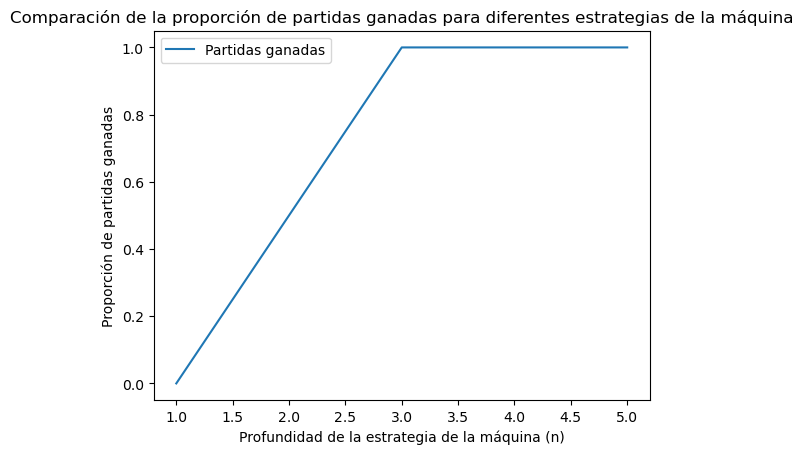

In [30]:
x = np.array(range(1,6))
y = np.array(partidas_ganadas)

#Gráfico partidas ganadas
fig, ax = plt.subplots() 
ax.plot(x, y, label = 'Partidas ganadas') 


ax.set_xlabel('Profundidad de la estrategia de la máquina (n)') 
ax.set_ylabel('Proporción de partidas ganadas') 

ax.set_title('Comparación de la proporción de partidas ganadas para diferentes estrategias de la máquina') 

ax.legend() 

plt.show() 


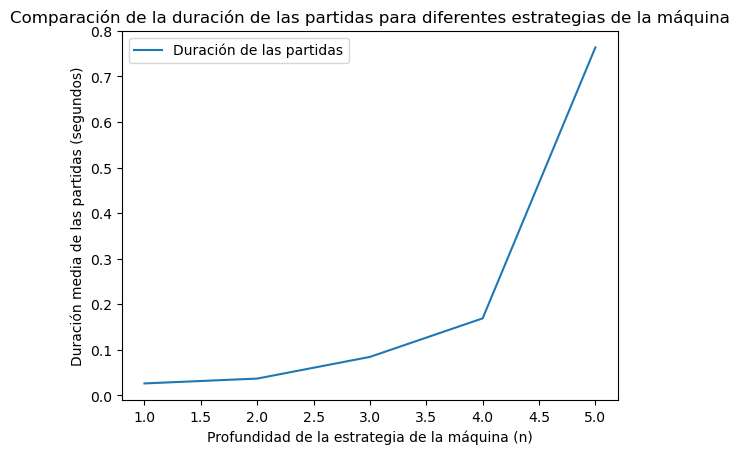

In [35]:
y2 = np.array(duracion_partidas)

#Gráfico de la duración media de las partidas
fig, ax = plt.subplots() 
ax.plot(x, y2, label = 'Duración de las partidas') 


ax.set_xlabel('Profundidad de la estrategia de la máquina (n)') 
ax.set_ylabel('Duración media de las partidas (segundos)') 

ax.set_title('Comparación de la duración de las partidas para diferentes estrategias de la máquina') 

ax.legend() 

plt.show() 